
# Q-Learning: Robot de Logística en Fábrica Automatizada 🏭🤖

# Integrantes:

- Over Haider C. V.
- Luis Andres M. E.

## Introducción
Este script demuestra cómo un robot de logística autónomo puede aprender a navegar
desde el almacén hasta la zona de despacho en una fábrica, evitando obstáculos.

---

### 📦 Configuración del entorno de la fábrica

In [1]:
# =============================================================================
# 📦 IMPORTACIÓN DE LIBRERÍAS
# =============================================================================

import random
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches

In [2]:

# =============================================================================
# 🏭 CONFIGURACIÓN DEL ENTORNO DE LA FÁBRICA
# =============================================================================

# Configuración de la fábrica 5x5
grid_size = 5
estados = [(i, j) for i in range(grid_size) for j in range(grid_size)]

acciones = ["arriba", "abajo", "izquierda", "derecha"]

# Definición del mapa de la fábrica
# 🔵 🟩 ⛔ 🟩 🟩
# 🟩 ⛔ 🟩 ⛔ 🟩
# 🟩 🟩 🟩 ⛔ 🟩
# ⛔ ⛔ 🟩 🟩 ⛔
# 🟩 🟩 🟩 🟩 🟡

obstaculos = {(0, 2), (1, 1), (1, 3), (2, 3), (3, 0), (3, 1), (3, 4)}

punto_inicio = (0, 0)  # 🔵 Almacén
zona_despacho = (4, 4)  # 🟡 Meta

In [3]:
# =============================================================================
# 🎯 SISTEMA DE RECOMPENSAS DE LA FÁBRICA
# =============================================================================


def obtener_recompensa(estado_actual, accion, nuevo_estado):
    """
    Calcula la recompensa basada en el estado actual, acción y nuevo estado

    Parámetros:
    - estado_actual: tupla (i, j) del estado donde está el robot
    - accion: string con la acción ejecutada
    - nuevo_estado: tupla (i, j) del estado resultante

    Retorna:
    - recompensa: int con el valor de la recompensa
    """
    # Si el robot intenta moverse fuera del mapa
    i, j = nuevo_estado
    if i < 0 or i >= grid_size or j < 0 or j >= grid_size:
        return -100

    # Si el robot choca contra un obstáculo
    if nuevo_estado in obstaculos:
        return -100

    # Si el robot llega a la zona de despacho
    if nuevo_estado == zona_despacho:
        return +100

    # USANDO ESTADO_ACTUAL Y ACCION: Recompensa direccional hacia la meta
    # Calcular distancia Manhattan al objetivo antes y después del movimiento
    dist_actual = abs(estado_actual[0] - zona_despacho[0]) + abs(
        estado_actual[1] - zona_despacho[1]
    )
    dist_nueva = abs(nuevo_estado[0] - zona_despacho[0]) + abs(
        nuevo_estado[1] - zona_despacho[1]
    )

    # Recompensa base por cada paso
    recompensa_base = -1

    # Bonificación si se acerca a la meta
    if dist_nueva < dist_actual:
        recompensa_direccional = +0.1  # Pequeña bonificación por acercarse
    elif dist_nueva > dist_actual:
        recompensa_direccional = -0.1  # Pequeña penalización por alejarse
    else:
        recompensa_direccional = 0  # Neutral si mantiene distancia

    # USANDO ACCION: Penalización adicional por intentar ir hacia obstáculos
    penalizacion_accion = 0
    if accion == "arriba":
        intento_estado = (estado_actual[0] - 1, estado_actual[1])
    elif accion == "abajo":
        intento_estado = (estado_actual[0] + 1, estado_actual[1])
    elif accion == "izquierda":
        intento_estado = (estado_actual[0], estado_actual[1] - 1)
    elif accion == "derecha":
        intento_estado = (estado_actual[0], estado_actual[1] + 1)

    # Si el robot intenta ir hacia un obstáculo (aunque no se mueva)
    if intento_estado in obstaculos and nuevo_estado == estado_actual:
        penalizacion_accion = -0.5  # Penalización por intentar ir hacia obstáculo

    return recompensa_base + recompensa_direccional + penalizacion_accion

In [4]:
# =============================================================================
# 🤖 FUNCIONES DE MOVIMIENTO DEL ROBOT
# =============================================================================

def siguiente_estado(estado, accion):
    """
    Determina el siguiente estado basado en la acción del robot

    Parámetros:
    - estado: tupla (i, j) posición actual
    - accion: string con la dirección del movimiento

    Retorna:
    - nuevo_estado: tupla (i, j) nueva posición
    """
    i, j = estado
    nuevo_estado = {
        "arriba": (max(0, i - 1), j),
        "abajo": (min(grid_size - 1, i + 1), j),
        "izquierda": (i, max(0, j - 1)),
        "derecha": (i, min(grid_size - 1, j + 1)),
    }[accion]

    # Si el nuevo estado es un obstáculo, el robot se queda en el mismo lugar
    if nuevo_estado in obstaculos:
        return estado

    return nuevo_estado

In [5]:
# =============================================================================
# 📊 VISUALIZACIÓN DEL ENTORNO
# =============================================================================


def visualizar_entorno_fabrica():
    """Visualiza el mapa de la fábrica con obstáculos y zonas importantes"""
    plt.figure(figsize=(10, 8))

    # Crear el fondo base
    plt.imshow(np.ones((grid_size, grid_size)), cmap="Greens", alpha=0.3)

    # Dibujar obstáculos
    for i, j in obstaculos:
        plt.scatter(j, i, color="red", s=400, marker="s")
        plt.text(j, i, "⛔", ha="center", va="center", fontsize=16)

    # Dibujar punto de inicio (almacén)
    plt.scatter(punto_inicio[1], punto_inicio[0], color="blue", s=400, marker="o")
    plt.text(
        punto_inicio[1], punto_inicio[0], "🔵", ha="center", va="center", fontsize=16
    )

    # Dibujar zona de despacho (meta)
    plt.scatter(zona_despacho[1], zona_despacho[0], color="gold", s=400, marker="*")
    plt.text(
        zona_despacho[1], zona_despacho[0], "🟡", ha="center", va="center", fontsize=16
    )

    # Crear leyenda
    red_patch = mpatches.Patch(color="red", label="Zona Restringida ⛔ (-100)")
    blue_patch = mpatches.Patch(color="blue", label="Almacén 🔵 (inicio)")
    gold_patch = mpatches.Patch(color="gold", label="Zona Despacho 🟡 (+100)")
    green_patch = mpatches.Patch(color="green", label="Área Transitable 🟩 (-1)")

    plt.legend(
        handles=[blue_patch, green_patch, red_patch, gold_patch],
        loc="upper center",
        bbox_to_anchor=(0.5, 1.15),
        ncol=2,
    )

    plt.title("Mapa de la Fábrica Automatizada 🏭", fontsize=14, fontweight="bold")
    plt.grid(True, alpha=0.3)
    plt.xticks(range(grid_size))
    plt.yticks(range(grid_size))
    plt.gca().invert_yaxis()
    plt.show()

🏭 CONFIGURACIÓN DE LA FÁBRICA AUTOMATIZADA
Tamaño del mapa: 5x5
Total de estados: 25
Acciones disponibles: ['arriba', 'abajo', 'izquierda', 'derecha']
Punto de inicio (almacén): (0, 0)
Zona de despacho (meta): (4, 4)
Obstáculos: {(2, 3), (0, 2), (3, 4), (3, 1), (1, 1), (1, 3), (3, 0)}



c:\Users\overd\Links\Academia\Inteligent\Systems\Partials\Two\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127981 (\N{FACTORY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\overd\Links\Academia\Inteligent\Systems\Partials\Two\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9940 (\N{NO ENTRY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\overd\Links\Academia\Inteligent\Systems\Partials\Two\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\overd\Links\Academia\Inteligent\Systems\Partials\Two\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\overd\Links\Academia\Inteligent\Sy

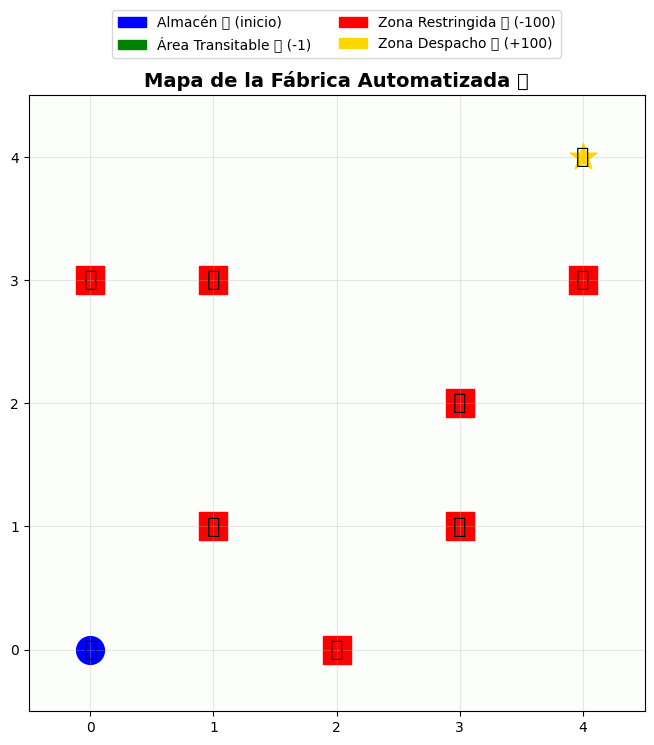

In [6]:
# =============================================================================
# ⚙️ CONFIGURACIÓN INICIAL Y MOSTRAR INFORMACIÓN
# =============================================================================

# Inicializar Q-table
Q = {estado: {accion: 0 for accion in acciones} for estado in estados}

# Mostrar configuración inicial
print("🏭 CONFIGURACIÓN DE LA FÁBRICA AUTOMATIZADA")
print("=" * 50)
print(f"Tamaño del mapa: {grid_size}x{grid_size}")
print(f"Total de estados: {len(estados)}")
print(f"Acciones disponibles: {acciones}")
print(f"Punto de inicio (almacén): {punto_inicio}")
print(f"Zona de despacho (meta): {zona_despacho}")
print(f"Obstáculos: {obstaculos}")
print()

# Visualizar el entorno
visualizar_entorno_fabrica()

In [7]:
# =============================================================================
# 🧠 PARÁMETROS DE Q-LEARNING
# =============================================================================

# Parámetros de Q-Learning para la fábrica
alpha = 0.7  # learning rate
gamma = 0.9  # discount factor
epsilon = 1.0  # exploración inicial
epsilon_decay = 0.01  # decay por episodio
episodios = 1000
max_pasos = 50  # máximo de pasos por episodio

print("🧠 PARÁMETROS DE Q-LEARNING")
print("=" * 30)
print(f"Learning rate (α): {alpha}")
print(f"Discount factor (γ): {gamma}")
print(f"Exploración inicial (ε): {epsilon}")
print(f"Epsilon decay: {epsilon_decay}")
print(f"Episodios: {episodios}")
print(f"Máximo pasos por episodio: {max_pasos}")
print()

🧠 PARÁMETROS DE Q-LEARNING
Learning rate (α): 0.7
Discount factor (γ): 0.9
Exploración inicial (ε): 1.0
Epsilon decay: 0.01
Episodios: 1000
Máximo pasos por episodio: 50



In [8]:
# =============================================================================
# 🚀 ENTRENAMIENTO DEL ROBOT CON Q-LEARNING
# =============================================================================

print("🚀 INICIANDO ENTRENAMIENTO DEL ROBOT...")
print()

recompensas_por_episodio = []
pasos_por_episodio = []
episodios_exitosos = 0

for episodio in range(episodios):
    estado_actual = punto_inicio
    recompensa_total = 0
    pasos = 0
    exito = False

    while estado_actual != zona_despacho and pasos < max_pasos:
        # Estrategia ε-greedy
        if random.uniform(0, 1) < epsilon:
            accion = random.choice(acciones)
        else:
            accion = max(Q[estado_actual], key=Q[estado_actual].get)

        # Ejecutar acción
        nuevo_estado = siguiente_estado(estado_actual, accion)
        recompensa = obtener_recompensa(estado_actual, accion, nuevo_estado)

        # Actualizar Q-table usando ecuación de Bellman
        q_actual = Q[estado_actual][accion]
        q_futuro_max = max(Q[nuevo_estado].values())

        Q[estado_actual][accion] = q_actual + alpha * (
            recompensa + gamma * q_futuro_max - q_actual
        )

        # Actualizar estado y métricas
        estado_actual = nuevo_estado
        recompensa_total += recompensa
        pasos += 1

        # Verificar si llegó a la meta
        if estado_actual == zona_despacho:
            exito = True
            episodios_exitosos += 1
            break

    # Reducir epsilon progresivamente
    epsilon = max(0.01, epsilon - epsilon_decay)

    recompensas_por_episodio.append(recompensa_total)
    pasos_por_episodio.append(pasos)

    # Mostrar progreso cada 100 episodios
    if (episodio + 1) % 100 == 0:
        print(
            f"Episodio {episodio + 1}: Recompensa = {recompensa_total:.1f}, "
            f"Pasos = {pasos}, Epsilon = {epsilon:.3f}"
        )

print()
print("✅ ENTRENAMIENTO COMPLETADO")
print()

🚀 INICIANDO ENTRENAMIENTO DEL ROBOT...

Episodio 100: Recompensa = 93.7, Pasos = 8, Epsilon = 0.010
Episodio 200: Recompensa = 93.7, Pasos = 8, Epsilon = 0.010
Episodio 300: Recompensa = 93.7, Pasos = 8, Epsilon = 0.010
Episodio 400: Recompensa = 93.7, Pasos = 8, Epsilon = 0.010
Episodio 500: Recompensa = 93.7, Pasos = 8, Epsilon = 0.010
Episodio 600: Recompensa = 93.7, Pasos = 8, Epsilon = 0.010
Episodio 700: Recompensa = 93.7, Pasos = 8, Epsilon = 0.010
Episodio 800: Recompensa = 93.7, Pasos = 8, Epsilon = 0.010
Episodio 900: Recompensa = 93.7, Pasos = 8, Epsilon = 0.010
Episodio 1000: Recompensa = 93.7, Pasos = 8, Epsilon = 0.010

✅ ENTRENAMIENTO COMPLETADO



In [9]:
# =============================================================================
# 📊 ANÁLISIS DE RESULTADOS
# =============================================================================


def analizar_resultados():
    print("📊 ANÁLISIS DE RESULTADOS")
    print("=" * 30)
    print(
        f"Episodios exitosos: {episodios_exitosos}/{episodios} ({episodios_exitosos / episodios * 100:.1f}%)"
    )
    print(f"Recompensa promedio: {np.mean(recompensas_por_episodio):.2f}")
    print(f"Mejor recompensa: {max(recompensas_por_episodio)}")
    print(f"Pasos promedio: {np.mean(pasos_por_episodio):.2f}")
    print(f"Menos pasos utilizados: {min(pasos_por_episodio)}")
    print()


analizar_resultados()

📊 ANÁLISIS DE RESULTADOS
Episodios exitosos: 985/1000 (98.5%)
Recompensa promedio: 90.41
Mejor recompensa: 93.7
Pasos promedio: 9.56
Menos pasos utilizados: 8



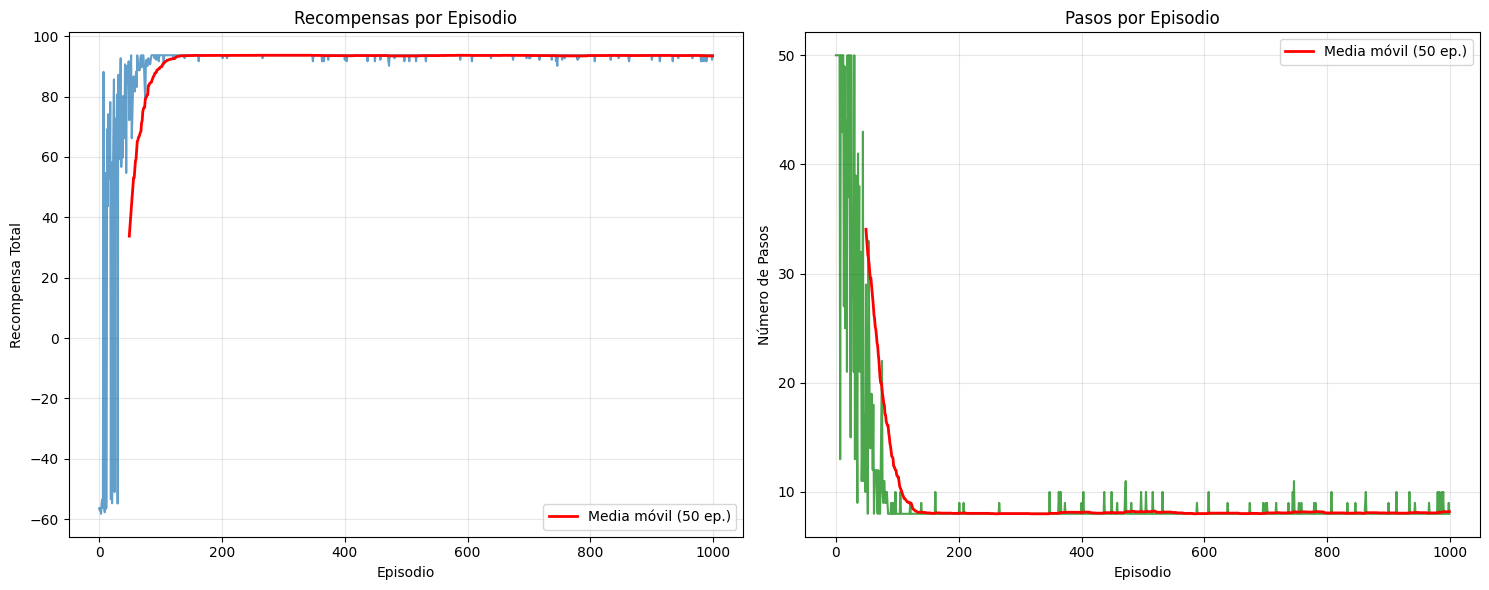

In [10]:
# =============================================================================
# 📈 VISUALIZACIÓN DEL PROGRESO DE ENTRENAMIENTO
# =============================================================================


def graficar_progreso():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # Gráfica de recompensas
    ax1.plot(recompensas_por_episodio, alpha=0.7)
    ventana = 50
    if len(recompensas_por_episodio) > ventana:
        media_movil = []
        for i in range(len(recompensas_por_episodio) - ventana + 1):
            media_movil.append(np.mean(recompensas_por_episodio[i : i + ventana]))
        ax1.plot(
            range(ventana - 1, len(recompensas_por_episodio)),
            media_movil,
            color="red",
            linewidth=2,
            label=f"Media móvil ({ventana} ep.)",
        )
        ax1.legend()

    ax1.set_title("Recompensas por Episodio")
    ax1.set_xlabel("Episodio")
    ax1.set_ylabel("Recompensa Total")
    ax1.grid(True, alpha=0.3)

    # Gráfica de pasos
    ax2.plot(pasos_por_episodio, alpha=0.7, color="green")
    if len(pasos_por_episodio) > ventana:
        media_movil_pasos = []
        for i in range(len(pasos_por_episodio) - ventana + 1):
            media_movil_pasos.append(np.mean(pasos_por_episodio[i : i + ventana]))
        ax2.plot(
            range(ventana - 1, len(pasos_por_episodio)),
            media_movil_pasos,
            color="red",
            linewidth=2,
            label=f"Media móvil ({ventana} ep.)",
        )
        ax2.legend()

    ax2.set_title("Pasos por Episodio")
    ax2.set_xlabel("Episodio")
    ax2.set_ylabel("Número de Pasos")
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


graficar_progreso()

c:\Users\overd\Links\Academia\Inteligent\Systems\Partials\Two\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


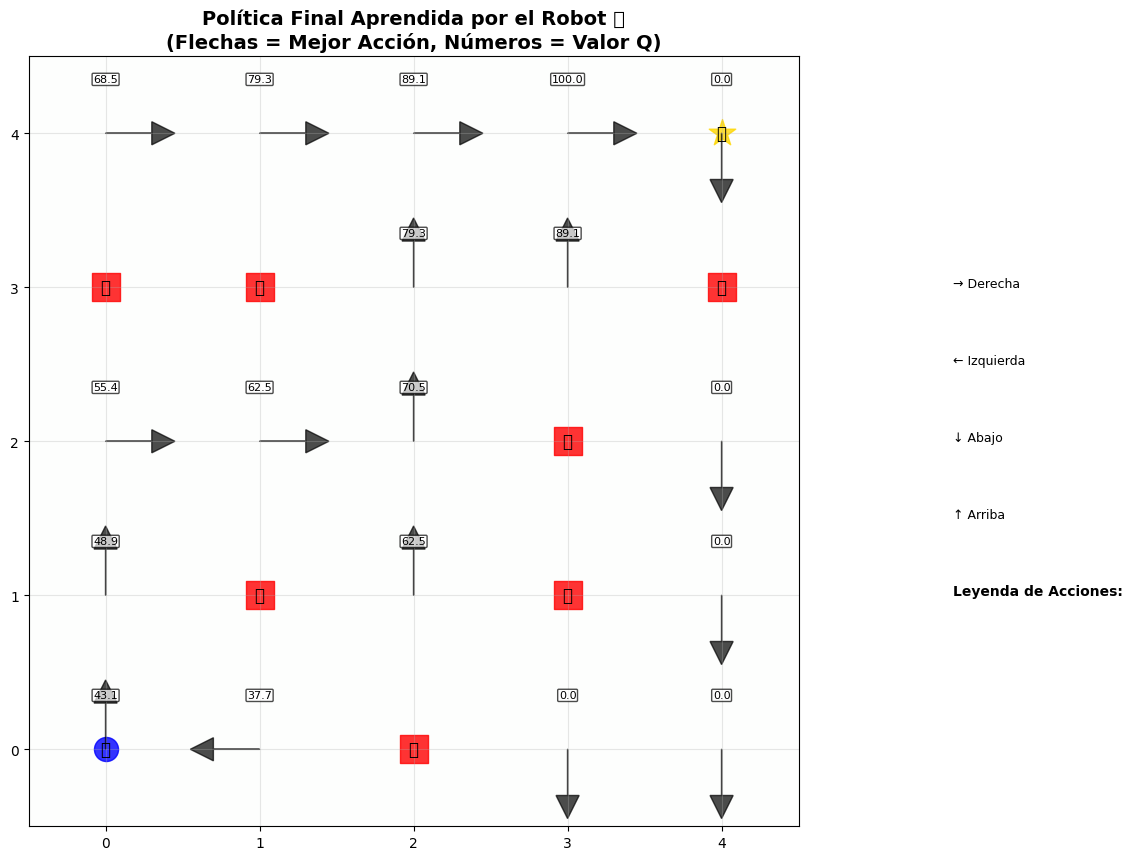

In [11]:

# =============================================================================
# 🗺️ VISUALIZACIÓN DE LA POLÍTICA APRENDIDA
# =============================================================================


def visualizar_politica_aprendida():
    """Muestra la política final aprendida por el robot"""
    plt.figure(figsize=(12, 10))

    # Crear fondo base
    plt.imshow(np.ones((grid_size, grid_size)), cmap="Greens", alpha=0.2)

    for i in range(grid_size):
        for j in range(grid_size):
            estado = (i, j)

            # Dibujar obstáculos
            if estado in obstaculos:
                plt.scatter(j, i, color="red", s=400, marker="s", alpha=0.8)
                plt.text(j, i, "⛔", ha="center", va="center", fontsize=12)
                continue

            # Dibujar inicio y meta
            if estado == punto_inicio:
                plt.scatter(j, i, color="blue", s=300, marker="o", alpha=0.8)
                plt.text(j, i, "🔵", ha="center", va="center", fontsize=12)
            elif estado == zona_despacho:
                plt.scatter(j, i, color="gold", s=400, marker="*", alpha=0.8)
                plt.text(j, i, "🟡", ha="center", va="center", fontsize=12)

            # Mostrar mejor acción aprendida
            mejor_accion = max(Q[estado], key=Q[estado].get)
            mejor_valor = max(Q[estado].values())

            # Dibujar flecha según la acción
            dx, dy = 0, 0
            if mejor_accion == "arriba":
                dy = -0.3
            elif mejor_accion == "abajo":
                dy = 0.3
            elif mejor_accion == "izquierda":
                dx = -0.3
            elif mejor_accion == "derecha":
                dx = 0.3

            if dx != 0 or dy != 0:
                plt.arrow(
                    j,
                    i,
                    dx,
                    dy,
                    head_width=0.15,
                    head_length=0.15,
                    fc="black",
                    ec="black",
                    alpha=0.7,
                )

            # Mostrar valor Q
            plt.text(
                j,
                i + 0.35,
                f"{mejor_valor:.1f}",
                ha="center",
                va="center",
                fontsize=8,
                bbox=dict(boxstyle="round,pad=0.1", facecolor="white", alpha=0.7),
            )

    plt.title(
        "Política Final Aprendida por el Robot 🤖\n(Flechas = Mejor Acción, Números = Valor Q)",
        fontsize=14,
        fontweight="bold",
    )
    plt.grid(True, alpha=0.3)
    plt.xticks(range(grid_size))
    plt.yticks(range(grid_size))
    plt.gca().invert_yaxis()

    # Leyenda
    plt.text(grid_size + 0.5, 1, "Leyenda de Acciones:", fontsize=10, fontweight="bold")
    plt.text(grid_size + 0.5, 1.5, "↑ Arriba", fontsize=9)
    plt.text(grid_size + 0.5, 2, "↓ Abajo", fontsize=9)
    plt.text(grid_size + 0.5, 2.5, "← Izquierda", fontsize=9)
    plt.text(grid_size + 0.5, 3, "→ Derecha", fontsize=9)

    plt.show()


# Mostrar política aprendida
visualizar_politica_aprendida()

In [12]:
# =============================================================================
# 🛣️ DEMOSTRACIÓN DE RUTA ÓPTIMA
# =============================================================================


def demostrar_ruta_optima():
    """Demuestra una ejecución usando la política aprendida"""
    print("🛣️  DEMOSTRACIÓN DE RUTA ÓPTIMA")
    print("=" * 35)

    estado = punto_inicio
    ruta = [estado]
    pasos = 0

    print(f"Inicio: {estado}")

    while estado != zona_despacho and pasos < max_pasos:
        mejor_accion = max(Q[estado], key=Q[estado].get)
        estado = siguiente_estado(estado, mejor_accion)
        ruta.append(estado)
        pasos += 1
        print(f"Paso {pasos}: {mejor_accion} → {estado}")

    if estado == zona_despacho:
        print(f"🎯 ¡Meta alcanzada en {pasos} pasos!")
        print(f"Ruta completa: {' → '.join(map(str, ruta))}")
    else:
        print("❌ No se pudo alcanzar la meta en el límite de pasos")

    return ruta


ruta_optima = demostrar_ruta_optima()

🛣️  DEMOSTRACIÓN DE RUTA ÓPTIMA
Inicio: (0, 0)
Paso 1: abajo → (1, 0)
Paso 2: abajo → (2, 0)
Paso 3: derecha → (2, 1)
Paso 4: derecha → (2, 2)
Paso 5: abajo → (3, 2)
Paso 6: abajo → (4, 2)
Paso 7: derecha → (4, 3)
Paso 8: derecha → (4, 4)
🎯 ¡Meta alcanzada en 8 pasos!
Ruta completa: (0, 0) → (1, 0) → (2, 0) → (2, 1) → (2, 2) → (3, 2) → (4, 2) → (4, 3) → (4, 4)


In [13]:
# =============================================================================
# 🏆 RESUMEN FINAL
# =============================================================================

print()
print("🏆 RESUMEN FINAL")
print("=" * 20)
print("El robot ha aprendido exitosamente a navegar en la fábrica")
print("desde el almacén hasta la zona de despacho, evitando obstáculos.")
print(f"Tasa de éxito final: {episodios_exitosos / episodios * 100:.1f}%")


🏆 RESUMEN FINAL
El robot ha aprendido exitosamente a navegar en la fábrica
desde el almacén hasta la zona de despacho, evitando obstáculos.
Tasa de éxito final: 98.5%
